# PCA for the analysis of historical facades

We study a dataset of historical facade descriptors such as height, width, symmetry, decorative content, and number of windows. The goal is to use **principal component analysis (PCA)** to:

1. identify the dominant directions of variation in the facade data,
2. visualize the facades in a low-dimensional PCA space,
3. interpret which geometric and stylistic features drive the principal components,
4. explore whether architectural styles tend to cluster in PCA coordinates.

This is a synthetic but realistic data-analysis task: the features are low-dimensional, interpretable, and naturally correlated.


## Learning goals

By the end of this notebook, you should be able to:

- clean and prepare a real tabular dataset for PCA,
- standardize features before applying PCA,
- compute PCA from the SVD of the standardized data matrix,
- interpret the singular values and explained variance,
- project samples onto the first principal components,
- interpret PCA loadings in terms of the original facade features,
- discuss whether architectural styles separate in a low-dimensional representation.


## 1. Load and clean the facade dataset

We use the uploaded file `historical_facades.csv`, which is placed in the local `data/` folder.

The dataset contains 100 facades with the following variables:

- height,
- width,
- height-to-width ratio,
- number of windows,
- presence of columns,
- symmetry score,
- decorative elements percentage,
- architectural style.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("data/historical_facades.csv")

numeric_cols = [
    "Height (m)",
    "Width (m)",
    "Height-to-Width Ratio",
    "Number of Windows",
    "Columns",
    "Symmetry",
    "Decorative Elements (%)",
]

print("Dataset shape:", df.shape)
print()
print(df.head())


Dataset shape: (100, 8)

   Height (m)  Width (m)  Height-to-Width Ratio  Number of Windows  Columns  \
0   29.889209   9.625933               3.105071                 17        0   
1   25.927066   8.186608               3.167010                 20        0   
2   24.092775  11.395041               2.114321                 25        1   
3   16.377896   8.174736               2.003477                 18        1   
4   22.076271  19.039773               1.159482                 23        1   

   Symmetry  Decorative Elements (%) Architectural Style  
0  0.903261                25.560268              Gothic  
1  0.807308                33.200189              Gothic  
2  0.870021                38.694876              Gothic  
3  0.722706                22.136131        Neoclassical  
4  0.867636                30.615058              Gothic  


## 2. Explore the raw facade features

Before computing PCA, we inspect the feature distributions and the architectural-style labels.

This helps us understand the scale and variability of the descriptors.


In [14]:
display(df[numeric_cols].describe())

style_counts = df["Architectural Style"].value_counts()
print(style_counts)


,Height (m),Width (m),Height-to-Width Ratio,Number of Windows,Columns,Symmetry,Decorative Elements (%)
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,21.530105,13.431223,1.750474,23.560000,0.820000,0.805993,36.036503
std,6.403462,3.881792,0.750940,9.393013,0.386123,0.138498,22.561084
min,9.318636,4.010584,0.578304,10.000000,0.000000,0.500292,10.194009
25%,16.687821,10.068148,1.187319,17.000000,1.000000,0.687574,19.815311
50%,21.407865,13.394381,1.643757,22.000000,1.000000,0.845657,28.687566
75%,24.600380,15.968355,2.133735,27.250000,1.000000,0.914725,53.998074
max,39.864483,23.955050,4.373586,49.000000,1.000000,0.997751,87.551315


Architectural Style
Gothic          38
Neoclassical    36
Baroque         26
Name: count, dtype: int64


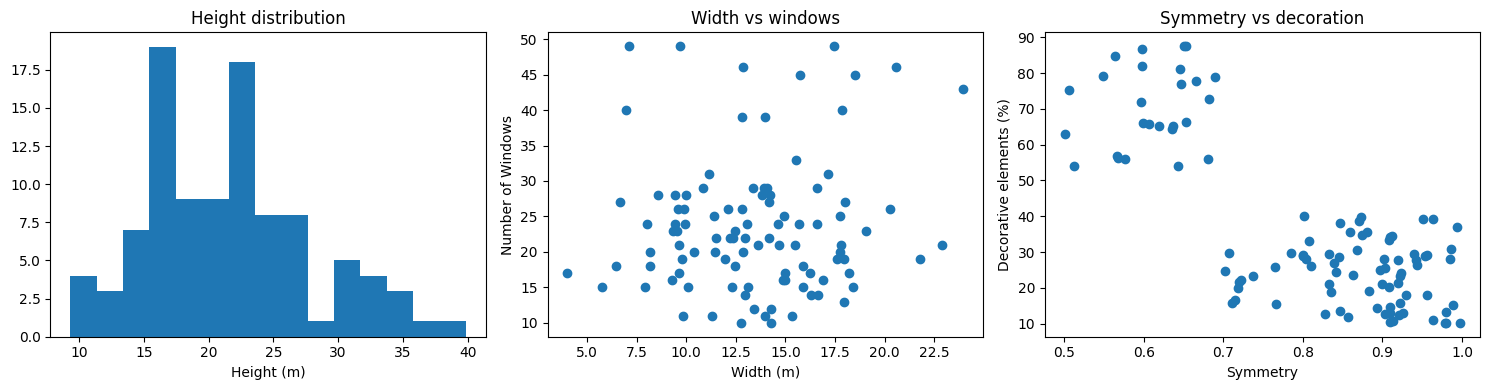

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["Height (m)"], bins=15)
axes[0].set_title("Height distribution")
axes[0].set_xlabel("Height (m)")

axes[1].scatter(df["Width (m)"], df["Number of Windows"])
axes[1].set_title("Width vs windows")
axes[1].set_xlabel("Width (m)")
axes[1].set_ylabel("Number of Windows")

axes[2].scatter(df["Symmetry"], df["Decorative Elements (%)"])
axes[2].set_title("Symmetry vs decoration")
axes[2].set_xlabel("Symmetry")
axes[2].set_ylabel("Decorative elements (%)")

plt.tight_layout()
plt.show()


## 3. Standardize the features

PCA is sensitive to scale, so we standardize each numeric feature:
$$
z_{ij} = \frac{x_{ij} - \mu_j}{s_j}.
$$

This ensures that features measured in different units contribute on a comparable scale.


In [5]:
def standardize_matrix(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=1)
    Xs = (X - mu) / sigma
    return Xs, mu, sigma
    
X = df[numeric_cols].to_numpy(dtype=float)
Xs, mu, sigma = standardize_matrix(X)

print(X.shape, Xs.shape)


(100, 7) (100, 7)


## 4. Compute PCA from the SVD

We compute the economy SVD of the standardized data matrix:
$$
X_s = U\Sigma V^T.
$$

For PCA:
- the columns of $V$ are the principal directions,
- the scores are given by
$$
Z = X_s V = U\Sigma,
$$
- the explained variances are proportional to the squared singular values.


In [6]:
U, s, VT = np.linalg.svd(Xs, full_matrices=False)
V = VT.T
Z = Xs @ V


## 5. Plot the singular values and explained variance

We now visualize:
- the singular value spectrum,
- the cumulative explained variance.

These plots help us decide how many principal components are needed to describe the facade data.


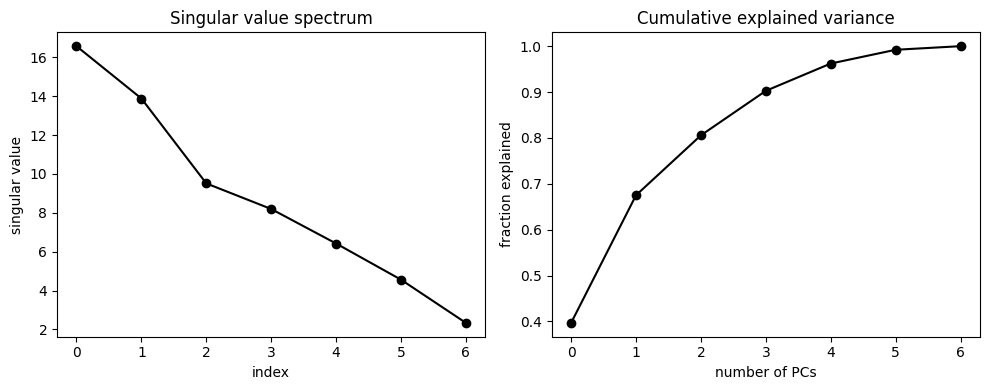

In [7]:
explained_variance = s**2 / (Xs.shape[0] - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(s, "o-k")
axes[0].set_title("Singular value spectrum")
axes[0].set_xlabel("index")
axes[0].set_ylabel("singular value")

axes[1].plot(cumulative_variance, "o-k")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("number of PCs")
axes[1].set_ylabel("fraction explained")

plt.tight_layout()
plt.show()


## 6. Visualize the facades in PCA coordinates

We now project the facades onto the first principal components and visualize them in a low-dimensional PCA space.

A good question is whether different architectural styles form partially separated clusters.


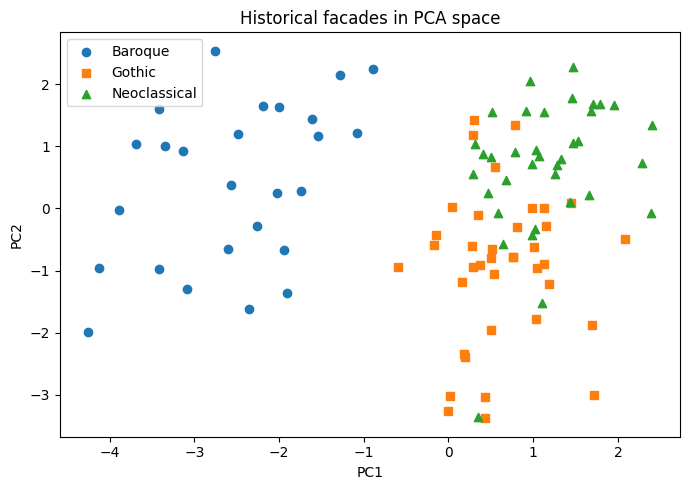

In [8]:
styles = sorted(df["Architectural Style"].unique())
markers = ["o", "s", "^", "D", "v", "P", "X"]

plt.figure(figsize=(7, 5))
for style, marker in zip(styles, markers):
    mask = df["Architectural Style"] == style
    plt.scatter(Z[mask, 0], Z[mask, 1], label=style, marker=marker)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Historical facades in PCA space")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Interpret the principal components

The coefficients of the principal directions tell us which facade features contribute most strongly to each component.

We inspect the loadings of the first two principal components.


In [9]:
loadings = pd.DataFrame(
    V[:, :2],
    index=numeric_cols,
    columns=["PC1", "PC2"]
)
display(loadings)

print("Largest absolute loading in PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False))

print()
print("Largest absolute loading in PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False))


,PC1,PC2
Height (m),-0.405065,-0.254198
Width (m),-0.100400,0.579197
Height-to-Width Ratio,-0.194467,-0.642299
Number of Windows,-0.478128,-0.011778
Columns,-0.129288,0.396412
Symmetry,0.505566,-0.145650
Decorative Elements (%),-0.535823,0.094183


Largest absolute loading in PC1:
Decorative Elements (%)    0.535823
Symmetry                   0.505566
Number of Windows          0.478128
Height (m)                 0.405065
Height-to-Width Ratio      0.194467
Columns                    0.129288
Width (m)                  0.100400
Name: PC1, dtype: float64

Largest absolute loading in PC2:
Height-to-Width Ratio      0.642299
Width (m)                  0.579197
Columns                    0.396412
Height (m)                 0.254198
Symmetry                   0.145650
Decorative Elements (%)    0.094183
Number of Windows          0.011778
Name: PC2, dtype: float64


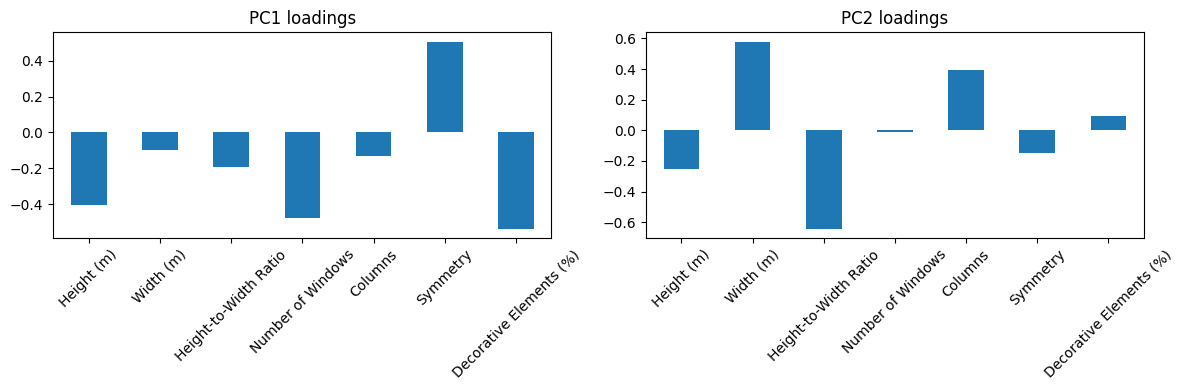

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

loadings["PC1"].plot(kind="bar", ax=axes[0])
axes[0].set_title("PC1 loadings")
axes[0].tick_params(axis="x", rotation=45)

loadings["PC2"].plot(kind="bar", ax=axes[1])
axes[1].set_title("PC2 loadings")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 8. Reconstruct facades from a low-dimensional PCA representation

Although this is not an image dataset, we can still reconstruct the numeric facade descriptors from the first few principal components.

For a chosen facade, compare:
- the original standardized descriptor vector,
- its reconstruction using only the first 2 principal components,
- its reconstruction using the first 3 principal components.


In [11]:
k = 0
z_k = Xs[k, :]

z_k_2 = Z[k, :2] @ V[:, :2].T
z_k_3 = Z[k, :3] @ V[:, :3].T


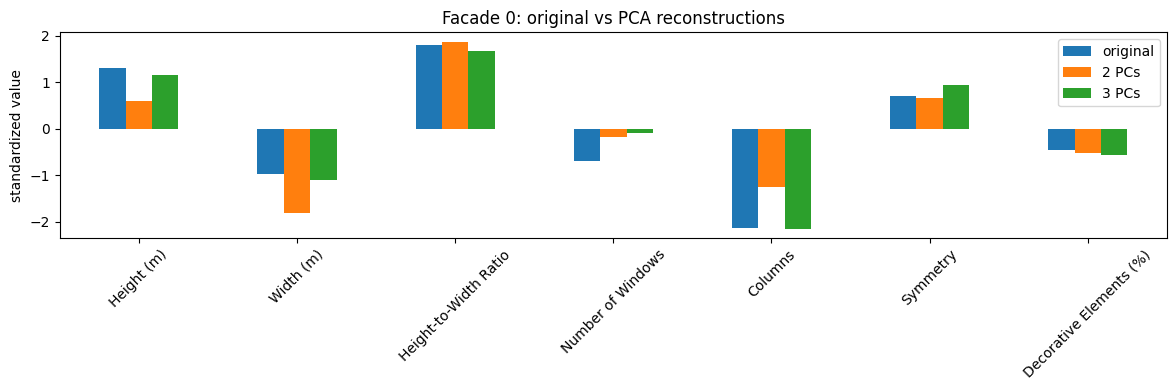

In [12]:
comparison = pd.DataFrame(
    {
        "original": z_k,
        "2 PCs": z_k_2,
        "3 PCs": z_k_3,
    },
    index=numeric_cols,
)

comparison.plot(kind="bar", figsize=(12, 4))
plt.title(f"Facade {k}: original vs PCA reconstructions")
plt.ylabel("standardized value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Final discussion

1. **Why is standardization important before applying PCA to facade descriptors?**  
   Because the variables are measured in different units and scales, and PCA would otherwise be dominated by the features with the largest numerical magnitude.

2. **How many principal components seem sufficient to capture most of the variance?**  
   This depends on the cumulative explained variance, but usually only a few components are needed to capture the main geometric variation.

3. **Which original features dominate PC1 and PC2?**  
   The answer comes from the loading vectors. PC1 often reflects a broad size or proportion trend, while PC2 may reflect stylistic contrast such as symmetry versus ornamentation.

4. **Do architectural styles appear to cluster in PCA space?**  
   Often there is partial clustering, although the classes may still overlap because the descriptors are low-dimensional and simplified.

5. **What information is lost when we reconstruct a facade using only 2 or 3 principal components?**  
   We lose the lower-variance details that may still be important for distinguishing subtle architectural differences.

6. **In an application to real heritage analysis, what other facade descriptors might be useful?**  
   Useful additions could include arch shape, door proportions, material type, roofline geometry, texture descriptors, or image-based features extracted from photographs.
